# 04 — Job Clustering & Topic Discovery (Unsupervised)

K-Means over the job TF-IDF vectors to discover natural job families, with the elbow method +
silhouette score to choose k, and a 2D projection (Truncated SVD) for visualization.

In [1]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models import recommender, clustering
from src import config

## 1. Load the job index (run notebook 03 first, or `scripts/train_all.py`)

In [2]:
job_corpus = pd.read_csv(config.JOB_CORPUS_CSV)
job_vectorizer, job_matrix = recommender.load_job_index()
job_matrix.shape

(58089, 25000)

## 2. Elbow method + silhouette score to choose k

In [3]:
k_eval = clustering.evaluate_k_range(job_matrix, k_range=range(4, 15), sample_size=4000)
k_eval

,k,inertia,silhouette
0,4,3750.680823,0.009587
1,5,3730.481408,0.010820
2,6,3721.552944,0.009991
3,7,3704.030529,0.010398
4,8,3693.376921,0.012866
5,9,3676.370158,0.014958
6,10,3664.623340,0.015017
7,11,3661.722597,0.013591
8,12,3651.635328,0.017227
9,13,3637.527040,0.016102


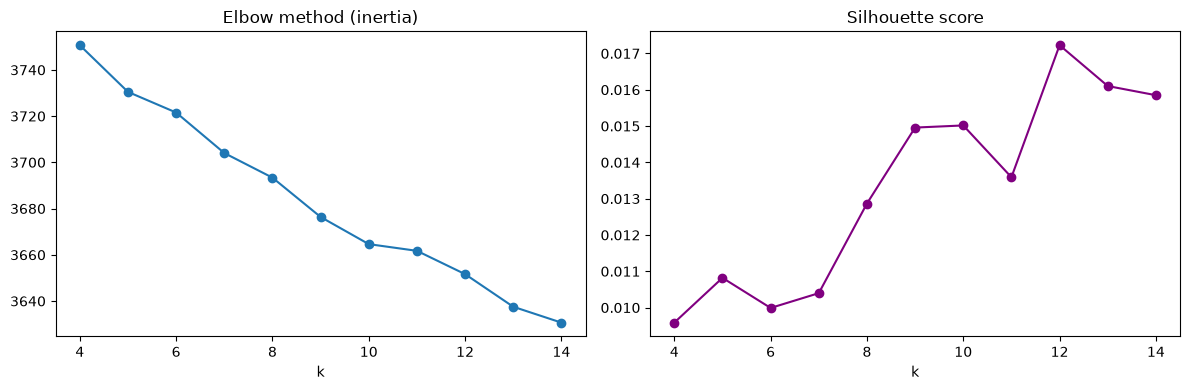

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(k_eval['k'], k_eval['inertia'], marker='o')
axes[0].set_title('Elbow method (inertia)')
axes[0].set_xlabel('k')

axes[1].plot(k_eval['k'], k_eval['silhouette'], marker='o', color='purple')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()

In [5]:
best_k = int(k_eval.loc[k_eval['silhouette'].idxmax(), 'k'])
print('Chosen k:', best_k)

Chosen k: 12


## 3. Fit K-Means at the chosen k

In [6]:
kmeans = clustering.fit_kmeans(job_matrix, best_k)
svd, coords_2d = clustering.fit_pca_2d(job_matrix)
clustering.save_clustering(kmeans, svd)
np.save(config.PROCESSED_DIR / 'job_cluster_labels.npy', kmeans.labels_)
np.save(config.PROCESSED_DIR / 'job_coords_2d.npy', coords_2d)

## 4. Visualize clusters in 2D

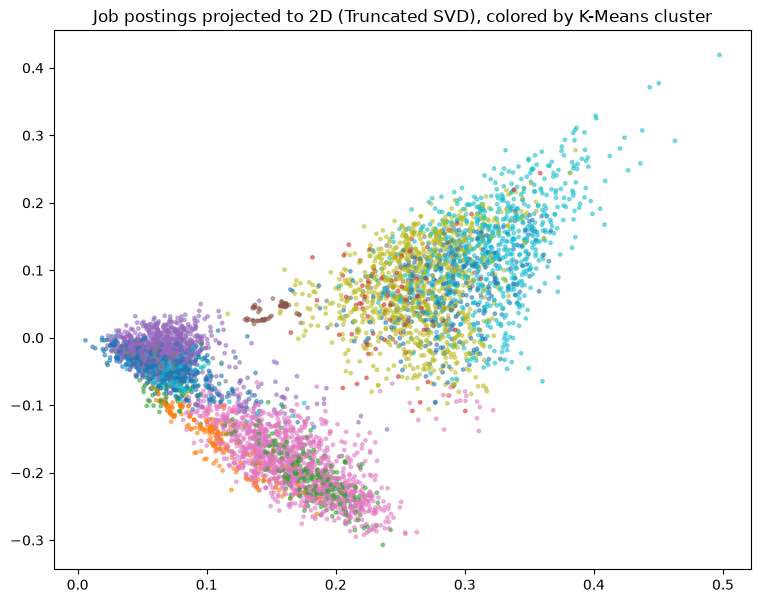

In [7]:
plt.figure(figsize=(9,7))
sample_idx = np.random.default_rng(42).choice(len(coords_2d), size=min(6000, len(coords_2d)), replace=False)
plt.scatter(coords_2d[sample_idx,0], coords_2d[sample_idx,1], c=kmeans.labels_[sample_idx], cmap='tab10', s=6, alpha=0.5)
plt.title('Job postings projected to 2D (Truncated SVD), colored by K-Means cluster')
plt.show()

## 5. Top terms per cluster (a lightweight topic model)

In [8]:
terms = clustering.top_terms_per_cluster(kmeans, job_vectorizer, top_n=12)
for cid, words in terms.items():
    print(f'Cluster {cid}:', ', '.join(words))

Cluster 0: management, manager, customer, operations, executive, service, customer service, office, support, data, sales, skills
Cluster 1: sales, business development, retail, sales sales, area sales, business, sales retail, sales job, retail business, development role, manager, sales role
Cluster 2: nurse, nursing, care, patients, patient, registered, rn, registered nurse, healthcare, patient care, health, nurse rn
Cluster 3: data, scientist, data scientist, machine, data science, machine learning, learning, python, science, sql, analytics, models
Cluster 4: accounts, finance, tax, audit, audit role, accounts finance, accounts accounts, company secretary, secretary, finance tax, tax company, secretary audit
Cluster 5: engineer, developer, development, engineering, data, application, software, sql, networking, senior, technical, python
Cluster 6: rs, professor, teaching, pay band, band, advertisement, pay, academic, date, ph, institute, technology bombay
Cluster 7: work, experience, t

In [9]:
import json
with open(config.PROCESSED_DIR / 'cluster_terms.json', 'w') as f:
    json.dump({str(k): v for k, v in terms.items()}, f, indent=2)

## Notes
- Silhouette scores for high-dimensional sparse TF-IDF text are typically low (0.01-0.05) compared to dense/geometric data — that's expected, not a bug. Relative comparison across k still tells us which k is best.
- For a richer topic model, try `sklearn.decomposition.NMF` or `LatentDirichletAllocation` on the same matrix (stretch goal from the project brief).